In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("12_speed_vs_stopping_distance.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  speed_kmh mileage_km_thousands maintenance_score driver_experience_years  \
0      42.0               191.38              4.19                      15   
1      82.0               137.92              3.21                       0   
2      77.0               150.09              7.49                       7   
3      43.0                45.92              8.66                       7   
4     115.0                52.04              6.36                      21   

   stopping_distance_m  
0                 31.0  
1                 53.0  
2                 56.0  
3                 26.0  
4                 94.0  

Shape of dataset:
(308, 5)

Columns:
Index(['speed_kmh', 'mileage_km_thousands', 'maintenance_score',
       'driver_experience_years', 'stopping_distance_m'],
      dtype='object')

Data types:
speed_kmh                   object
mileage_km_thousands        object
maintenance_score           object
driver_experience_years     object
stopping_distance_m        floa

In [2]:
# Convert required columns to numeric

df["speed_kmh"] = pd.to_numeric(
    df["speed_kmh"], errors="coerce"
)

df["stopping_distance_m"] = pd.to_numeric(
    df["stopping_distance_m"], errors="coerce"
)

# Remove missing values

df = df.dropna(
    subset=["speed_kmh", "stopping_distance_m"]
)

# Create binary target using median stopping distance

median_distance = df["stopping_distance_m"].median()

df["stopping_distance_class"] = (
    df["stopping_distance_m"] >= median_distance
).astype(int)

print("Median Stopping Distance:", median_distance)

print("\nBinary Target:")
print(df["stopping_distance_class"].value_counts())

print("\nDataset:")
print(df[[
    "speed_kmh",
    "stopping_distance_m",
    "stopping_distance_class"
]].head())

Median Stopping Distance: 54.0

Binary Target:
stopping_distance_class
1    150
0    143
Name: count, dtype: int64

Dataset:
   speed_kmh  stopping_distance_m  stopping_distance_class
0       42.0                 31.0                        0
1       82.0                 53.0                        0
2       77.0                 56.0                        1
3       43.0                 26.0                        0
4      115.0                 94.0                        1


In [3]:
# Input feature

X = df[["speed_kmh"]]

# Binary target variable

y = df["stopping_distance_class"]

print("Input Feature:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("stopping_distance_class")

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

Input Feature:
['speed_kmh']

Target Variable:
stopping_distance_class

Training data shape:
(234, 1)

Testing data shape:
(59, 1)


In [4]:
# Build Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

# Generate predictions

y_pred = model.predict(X_test)

print("Raw continuous predictions:")
print(y_pred[:10])

print("\nModel Coefficient:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Raw continuous predictions:
[0.51117374 0.51026221 0.51372603 0.51226758 0.5118422  0.51196373
 0.51226758 0.51111297 0.50941145 0.50953298]

Model Coefficient:
[6.07687322e-05]

Model Intercept:
0.5075883850265092


In [5]:
# Classification threshold

threshold = 0.5

# Convert continuous predictions into class labels

y_pred_class = (
    y_pred >= threshold
).astype(int)

# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred_class
)

print("Classification Threshold:", threshold)

print("\nPredicted Classes:")
print(y_pred_class[:10])

print("\nActual Classes:")
print(y_test.values[:10])

print("\nAccuracy:")
print(accuracy)

Classification Threshold: 0.5

Predicted Classes:
[1 1 1 1 1 1 1 1 1 1]

Actual Classes:
[0 0 1 1 1 0 0 0 0 0]

Accuracy:
0.4915254237288136


C:\Users\chait\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


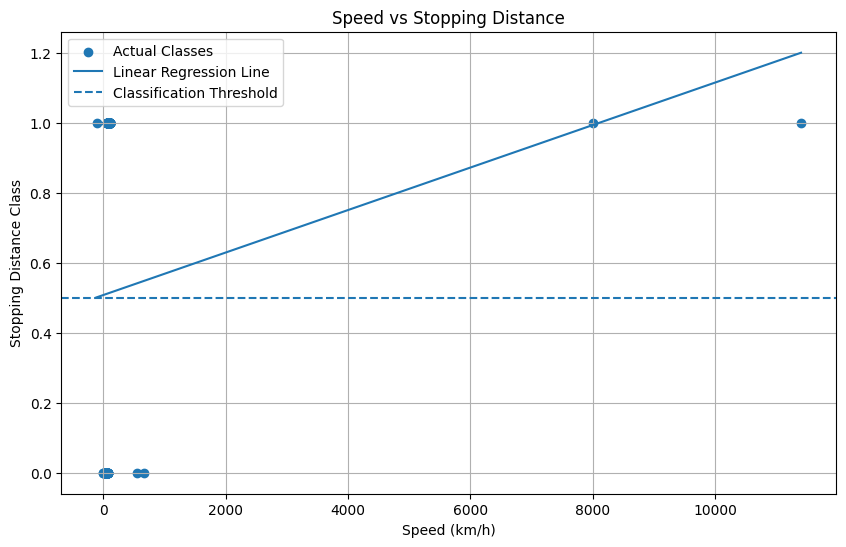

In [6]:
# Create values for regression line

X_line = np.linspace(
    X["speed_kmh"].min(),
    X["speed_kmh"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(X_line)

plt.figure(figsize=(10, 6))

# Actual observations

plt.scatter(
    X["speed_kmh"],
    y,
    label="Actual Classes"
)

# Linear Regression line

plt.plot(
    X_line,
    y_line,
    label="Linear Regression Line"
)

# Classification threshold

plt.axhline(
    y=threshold,
    linestyle="--",
    label="Classification Threshold"
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Stopping Distance Class")
plt.title("Speed vs Stopping Distance")

plt.legend()
plt.grid(True)

plt.show()

In [7]:
# Change classification threshold

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Comparison:\n")

for threshold in thresholds:

    y_pred_class = (
        y_pred >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_class
    )

    print(
        "Threshold:",
        threshold,
        "Accuracy:",
        accuracy
    )

Threshold Comparison:

Threshold: 0.3 Accuracy: 0.4915254237288136
Threshold: 0.4 Accuracy: 0.4915254237288136
Threshold: 0.5 Accuracy: 0.4915254237288136
Threshold: 0.6 Accuracy: 0.5084745762711864
Threshold: 0.7 Accuracy: 0.5084745762711864


In [8]:
# New observation

new_observation = pd.DataFrame({
    "speed_kmh": [80]
})

# Raw continuous prediction

raw_prediction = model.predict(
    new_observation
)[0]

# Classification threshold

threshold = 0.5

# Final class

final_class = int(
    raw_prediction >= threshold
)

print("New Observation:")
print(new_observation)

print("\nRaw Prediction:")
print(raw_prediction)

print("\nClassification Threshold:")
print(threshold)

print("\nFinal Class:")
print(final_class)

if final_class == 1:
    print("Interpretation: High Stopping Distance")
else:
    print("Interpretation: Low Stopping Distance")

New Observation:
   speed_kmh
0         80

Raw Prediction:
0.5124498836004989

Classification Threshold:
0.5

Final Class:
1
Interpretation: High Stopping Distance


In [ ]:
print("Limitations of Linear Regression for Binary Classification:")
print()
print("1. Linear Regression produces continuous output values.")
print("2. Predictions can be less than 0 or greater than 1.")
print("3. A classification threshold must be manually selected.")
print("4. The predicted values are not probabilities.")
print("5. Accuracy can change when the classification threshold changes.")
print()
print("Why Logistic Regression is preferred:")
print("Logistic Regression is specifically designed for binary classification.")
print("It produces probability values between 0 and 1.")
print("A classification threshold can then be used to assign class labels.")